# Object Detection on Wheat Dataset

1. Welcome to my Object Detection on Wheat dataset Project where I will going to detect where wheat clusters are present in an image with the help of Tensorflow custom model.
2. I will start with Efficient Data Ingestion approach with the help of Multiprocessing to utilize all the cores of our system.
3. Then I will going to create Data Generator capable of producing data in batches for Tensorflow models.
4. After that I will create custom Loss Function with the help of which we will get accurate error score which going to optimize our model training.
5. Then I will going to train our Tensorflow Object Detection model.
6. After that I will validate our model's prediction by looking at predicted bounding boxes of validation images.
7. Then I will present some points which can help our model to provide even better predictions.

In [1]:
import numpy as np 
import pandas as pd
import random 
import tensorflow as tf 
from tensorflow.keras.layers import Add, Input, BatchNormalization, LeakyReLU, Conv2D, Dropout 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.models import Model
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import pickle
import time

In [2]:
TESTING = True
if TESTING:
    normal_start_time = time.time()


In [3]:
path = "/kaggle/input/competitions/global-wheat-detection/"
train_path = path + "train/"
test_path = path + "test/" 
csv_path = path + "train.csv"

In [4]:
train = pd.read_csv(csv_path)
train.head()

,image_id,width,height,bbox,source
0,b6ab77fd7,1024,1024,"[834.0, 222.0, 56.0, 36.0]",usask_1
1,b6ab77fd7,1024,1024,"[226.0, 548.0, 130.0, 58.0]",usask_1
2,b6ab77fd7,1024,1024,"[377.0, 504.0, 74.0, 160.0]",usask_1
3,b6ab77fd7,1024,1024,"[834.0, 95.0, 109.0, 107.0]",usask_1
4,b6ab77fd7,1024,1024,"[26.0, 144.0, 124.0, 117.0]",usask_1


In [5]:
ALL_IMAGES = train.image_id.unique()
np.random.shuffle(ALL_IMAGES) 
ALL_IMAGES

array(['e3f4e8b6d', '4e6891a56', '681baf2e2', ..., '02640d9da',
       '060740e25', '817ab3693'], dtype=object)

In [6]:
IMAGE_SHAPE = (256, 256,)
CHANNELS = 3

In [7]:
SPLIT_SIZE = .90
train_size = int(len(ALL_IMAGES) * SPLIT_SIZE)

train_images = ALL_IMAGES[:train_size] 
valid_images = ALL_IMAGES[train_size:]

In [8]:
def load_image(name, path):
    global IMAGE_SHAPE
    img = Image.open(path + name + ".jpg")
    img = img.resize(IMAGE_SHAPE)
    return np.asarray(img) 

def load_bbox(name, path, df):
    sample = df[df["image_id"]==name]
    return sample["bbox"].str.slice(start = 1, stop = -1).str.split(", ", expand = True).astype(float).values / 4 

def getImageData(image_list, path, df):
    image_pixels, image_bboxes = {}, {}
    for name in tqdm(image_list, desc = "Loading Images and BBoxes"):
        image_pixels[name] = load_image(name, path) 
        image_bboxes[name] = load_bbox(name, path, df)
    return image_pixels, image_bboxes

In [9]:
if TESTING:
    normal_start_time = time.time()
    train_pixels, train_bboxes = getImageData(train_images, train_path, train)
    valid_pixels, valid_bboxes = getImageData(valid_images, train_path, train)
    normal_end_time = time.time()
    
    normal_time_taken = normal_end_time - normal_start_time 
    print(f"Without MultiProcessing time taken to load image and their bboxes is: {normal_time_taken:.0f} seconds")

Loading Images and BBoxes:   0%|          | 0/3035 [00:00<?, ?it/s]

Loading Images and BBoxes:   0%|          | 0/338 [00:00<?, ?it/s]

Without MultiProcessing time taken to load image and their bboxes is: 166 seconds


In [10]:
%%writefile GetImageData.py

import pandas as pd
import numpy as np
from PIL import Image
from multiprocessing import Pool
import pickle

def load_image(name, path):
    global IMAGE_SHAPE
    img = Image.open(path + name + ".jpg")
    img = img.resize(IMAGE_SHAPE)
    return np.asarray(img) 

def load_bbox(name, path, df):
    sample = df[df["image_id"]==name]
    return sample["bbox"].str.slice(start = 1, stop = -1).str.split(", ", expand = True).astype(float).values / 4 

def getImageData(TUPLE):
    name, path, df = TUPLE
    return name, load_image(name, path), load_bbox(name, path, df)

if __name__ == "__main__":
    path = "/kaggle/input/competitions/global-wheat-detection/"
    train_path = path + "train/"
    test_path = path + "test/" 
    csv_path = path + "train.csv"
    train = pd.read_csv(csv_path)
    
    ALL_IMAGES = train.image_id.unique()
    np.random.shuffle(ALL_IMAGES) 

    SPLIT_SIZE = .90
    train_size = int(len(ALL_IMAGES) * SPLIT_SIZE)

    train_images = ALL_IMAGES[:train_size] 
    valid_images = ALL_IMAGES[train_size:]


    IMAGE_SHAPE = (256, 256,)
    CHANNELS = 3

    train_pixels, train_bboxes = {}, {}
    valid_pixels, valid_bboxes = {}, {}

    with Pool(4) as p:
        for nm, px, bb in p.map(getImageData, [(name, train_path, train) for name in train_images]):
            train_pixels[nm] = px
            train_bboxes[nm] = bb
        for nm, px, bb in p.map(getImageData, [(name, train_path, train) for name in valid_images]):
            valid_pixels[nm] = px
            valid_bboxes[nm] = bb 

    pickle.dump(train_pixels, open("./train_pixels.pkl", "wb"))
    pickle.dump(train_bboxes, open("./train_bboxes.pkl", "wb"))
    pickle.dump(valid_pixels, open("./valid_pixels.pkl", "wb"))
    pickle.dump(valid_bboxes, open("./valid_bboxes.pkl", "wb"))
    pickle.dump(train_images, open("./train_images.pkl", "wb"))
    pickle.dump(valid_images, open("./valid_images.pkl", "wb"))

Writing GetImageData.py


In [11]:
multi_start_time = time.time()
!python GetImageData.py

train_bboxes = pickle.load(open("./train_bboxes.pkl", "rb"))
train_pixels = pickle.load(open("./train_pixels.pkl", "rb"))
valid_bboxes = pickle.load(open("./valid_bboxes.pkl", "rb"))
valid_pixels = pickle.load(open("./valid_pixels.pkl", "rb"))
train_images = pickle.load(open("./train_images.pkl", "rb"))
valid_images = pickle.load(open("./valid_images.pkl", "rb"))

multi_end_time = time.time()
multi_time_taken = multi_end_time - multi_start_time

print(f"With MultiProcessing time taken to load image and their bboxes is: {multi_time_taken:.0f} seconds")

With MultiProcessing time taken to load image and their bboxes is: 50 seconds


In [12]:
if TESTING:
    print(f"Time Saved by using MultiProcessing is: {normal_time_taken - multi_time_taken:.0f} seconds")

Time Saved by using MultiProcessing is: 116 seconds


In [13]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_list, image_pixels, image_bboxes, batch_size=6, shuffle=False, dim=16,):
        global IMAGE_SHAPE, CHANNELS
        self.image_list = image_list
        self.image_pixels = image_pixels
        self.image_bboxes = image_bboxes
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.total_images = len(self.image_list)
        self.dim = dim
        self.IMAGE_SHAPE = IMAGE_SHAPE
        self.CHANNELS = CHANNELS
        self.IMAGE_GRID = self.image_grid()
        self.on_epoch_end()

    def image_grid(self):
        IMAGE_GRID = np.zeros((self.dim, self.dim, 4))
        stride = self.IMAGE_SHAPE[0] / self.dim
        for row in range(self.dim):
            for col in range(self.dim):
                IMAGE_GRID[col, row] = [stride * row, stride * col, stride, stride] 
        return IMAGE_GRID

    def __len__(self):
        return self.total_images // self.batch_size

    def on_epoch_end(self):
        self.indexes = [i for i in range(self.total_images)]
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indices = self.indexes[index*self.batch_size : (index+1)*self.batch_size]
        
        X = np.empty((self.batch_size, *self.IMAGE_SHAPE, self.CHANNELS)) # batch_size, 256, 256, 3
        y = np.empty((self.batch_size, self.dim, self.dim, 5))  # batch_size, 16, 16, 5(prob, x, y, w, h)

        for _, idx in enumerate(batch_indices):
            X[_] = self.image_pixels[self.image_list[self.indexes[idx]]]
            bboxes = self.image_bboxes[self.image_list[self.indexes[idx]]]
            y[_] = self.process_bboxes(bboxes) 
        return X, y

    def process_bboxes(self, bboxes):
        LABEL = np.zeros((self.dim, self.dim, 5))
        
        for row in range(self.dim):
            for col in range(self.dim):
                
                cell = self.IMAGE_GRID[row, col].copy()
                cx, cy, cw, ch = cell
                cx2, cy2 = cx+cw, cy+ch

                for bbox in bboxes:
                    x, y, w, h = bbox
                    xc = x + w/2
                    yc = y + h/2

                    if xc>=cx and xc<cx2 and yc>=cy and yc<cy2:
                        bx, by, bw, bh = self.YoloShape((xc, yc, w, h), cell)
                        LABEL[row, col] = [1, bx, by, bw, bh]
                        
        return LABEL 

    def YoloShape(self, bbox, cell):
        xc, yc, w, h = bbox
        cx, cy, cw, ch = cell
        xc = (xc-cx)/cw
        yc = (yc-cy)/ch
        return xc, yc, w/256, h/256 

In [14]:
batch_size = 6 
shuffle = True
dim = 16

In [15]:
train_gen = DataGenerator(train_images, train_pixels, train_bboxes, batch_size = batch_size, shuffle = shuffle, dim = dim)
valid_gen = DataGenerator(valid_images, valid_pixels, valid_bboxes, batch_size = 2, shuffle = False, dim = dim)
IMAGE_GRID = train_gen.IMAGE_GRID

In [16]:
def getModel(labels=5,alpha=.1, dropout=1,):
    input_ = Input(shape = (*IMAGE_SHAPE, CHANNELS))
    x = Conv2D(filters = 32, kernel_size = 3, strides = 1, padding = "same")(input_)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha)(x)

    ## B1 ##
    x = Conv2D(filters = 64, kernel_size = 3, strides = 1, padding = "same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha)(x)
    res_x = x 

    for i in range(2):
        x = Conv2D(filters = 32, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Conv2D(filters = 64, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Add()([res_x, x]) 
        x = LeakyReLU(alpha)(x)
        if dropout:
            x = Dropout(.05)(x)
        res_x = x

    ## B2 ##
    x = Conv2D(filters = 128, kernel_size = 3, strides = 2, padding = "same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha)(x)
    res_x = x 

    for i in range(2):
        x = Conv2D(filters = 64, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Conv2D(filters = 128, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Add()([res_x, x]) 
        x = LeakyReLU(alpha)(x)
        if dropout:
            x = Dropout(.05)(x)
        res_x = x 

    ## B3 ##
    x = Conv2D(filters = 256, kernel_size = 3, strides = 2, padding = "same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha)(x)
    res_x = x 

    for i in range(8):
        x = Conv2D(filters = 128, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Conv2D(filters = 256, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Add()([res_x, x]) 
        x = LeakyReLU(alpha)(x)
        if dropout:
            x = Dropout(.1)(x)
        res_x = x

    ## B4 ##
    x = Conv2D(filters = 512, kernel_size = 3, strides = 2, padding = "same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha)(x)
    res_x = x 

    for i in range(8):
        x = Conv2D(filters = 256, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Conv2D(filters = 512, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Add()([res_x, x]) 
        x = LeakyReLU(alpha)(x)
        if dropout:
            x = Dropout(.1)(x)
        res_x = x

    ## B5 ##
    x = Conv2D(filters = 1024, kernel_size = 3, strides = 2, padding = "same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha)(x)
    res_x = x 

    for i in range(4):
        x = Conv2D(filters = 512, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Conv2D(filters = 1024, kernel_size = 3, strides = 1, padding = "same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha)(x)

        x = Add()([res_x, x]) 
        x = LeakyReLU(alpha)(x)
        if dropout:
            x = Dropout(.15)(x)
        res_x =  x

    x = Conv2D(filters = 512, kernel_size = 3, strides = 1, padding = "same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha)(x)

    x = Conv2D(filters = 256, kernel_size = 3, strides = 1, padding = "same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha)(x)

    x = Conv2D(filters = 128, kernel_size = 3, strides = 1, padding = "same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha)(x)

    output_ = Conv2D(filters = labels, kernel_size = 1, strides = 1, activation = "sigmoid")(x)
    return Model(inputs = input_, outputs = output_)

In [19]:
#tf.experimental.numpy.experimental_enable_numpy_behavior()

In [17]:
def custom_loss(y_true, y_pred):
    bc = BinaryCrossentropy(reduction=None, axis = 0)
    ## losses.MSE going to return loss for each batch 
    ## whereas losses.MeanSqauredError going to return SumOverBatchsize which is not needed for xy and wh losses
    ## we need to multiply each true box with its prediction
    xy_mse = tf.keras.losses.MAE
    wh_mse = tf.keras.losses.MAE

    mask = tf.where(y_true[:,:,:,0]==0, .5, 5.)
    
    prob_loss = bc(
        y_true[:, :, :, 0],
        y_pred[:, :, :, 0]
    )

    prob_loss *= mask

    xy_loss = xy_mse(
        y_true[:, :, :, 1:3],
        y_pred[:, :, :, 1:3]
    ) * mask

    wh_loss = wh_mse(
        y_true[:, :, :, 3:5],
        y_pred[:, :, :, 3:5]
    ) * mask

    return prob_loss + tf.sqrt(xy_loss) + tf.sqrt(wh_loss + wh_loss)

In [18]:
model = getModel()
# model.summary()

I0000 00:00:1786173800.384629      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [19]:
model.compile(
    loss = custom_loss,
    optimizer = Adam(learning_rate = .001)
)

In [20]:
callbacks = [
    EarlyStopping(monitor = "val_loss", patience = 3, restore_best_weights = True, verbose = 1),
    ReduceLROnPlateau(monitor = "val_loss", patience = 2, factor = .1, mid_delta = .001, min_lr = .000001, verbose = 1)
]

In [31]:
history = model.fit(
    train_gen,
    validation_data = valid_gen,
    epochs = 8,
    callbacks = callbacks,
    initial_epoch = 4
)

Epoch 5/8
505/505 ━━━━━━━━━━━━━━━━━━━━ 150s 296ms/step - loss: 0.5349 - val_loss: 0.7136 - learning_rate: 0.0010
Epoch 6/8
505/505 ━━━━━━━━━━━━━━━━━━━━ 149s 295ms/step - loss: 0.5084 - val_loss: 0.5503 - learning_rate: 0.0010
Epoch 7/8
505/505 ━━━━━━━━━━━━━━━━━━━━ 149s 296ms/step - loss: 0.4866 - val_loss: 0.5416 - learning_rate: 0.0010
Epoch 8/8
505/505 ━━━━━━━━━━━━━━━━━━━━ 149s 295ms/step - loss: 0.4750 - val_loss: 0.5884 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 7.


In [32]:
predictions = model.predict(valid_gen)

169/169 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step


In [33]:
_ = 0 
for i in predictions[:, :, :, 0].flatten():
    if i >=.5: _+=1
_ # total predicted objects

14928

In [34]:
def predictionToBBox(predictions, IMAGE_GRID):
    predictions[:, :, 1] = ( predictions[:, :, 1] * IMAGE_GRID[:,:,2] ) + IMAGE_GRID[:,:,0]
    predictions[:, :, 2] = ( predictions[:, :, 2] * IMAGE_GRID[:,:,3] ) + IMAGE_GRID[:,:,1] 

    predictions[:, :, 3] =  predictions[:, :, 3] * 256
    predictions[:, :, 4] =  predictions[:, :, 4] * 256 

    predictions[:, :, 1] = predictions[:, :, 1] - (predictions[:, :, 3] / 2)
    predictions[:, :, 2] = predictions[:, :, 2] - (predictions[:, :, 4] / 2)

    predictions[:, :, 3] =  predictions[:, :, 3] + predictions[:, :, 1]
    predictions[:, :, 4] =  predictions[:, :, 4] + predictions[:, :, 2] 
    return predictions

def prepareBBoxesForNMS(bboxes):
    probs = bboxes[:,:,0].flatten()
    BBOXES = bboxes[:,:,1:].reshape(-1, 4)
    BBOXES = shiftXY(BBOXES)
    return BBOXES, probs

def shiftXY(BBOXES):
    x = BBOXES[:, 0].copy()
    y = BBOXES[:, 1].copy()
    x2 = BBOXES[:, 2].copy()
    y2 = BBOXES[:, 3].copy()

    BBOXES[:, 0] = y
    BBOXES[:, 1] = x
    BBOXES[:, 2] = y2
    BBOXES[:, 3] = x2 
    return BBOXES

def nonMaxSuppression(bboxes, probs, topn=10, score=.5, iou=.5):
    indices  = tf.image.non_max_suppression(
        boxes = bboxes,
        scores = probs,
        max_output_size = topn,
        score_threshold = score,
        iou_threshold = iou,   
    )

    return bboxes[indices].copy()

def getFilteredBBoxes(image_list, predictions, IMAGE_GRID, topn, score, iou):
    predictions = predictions.copy()
    BBOXES = {}
    for i, name in enumerate(image_list):
        bboxes = predictionToBBox(predictions[i], IMAGE_GRID)
        bboxes, probs = prepareBBoxesForNMS(bboxes) 
        bboxes = nonMaxSuppression(bboxes, probs, topn, score=score, iou=iou)
        BBOXES[name] = shiftXY(bboxes)
        
    return BBOXES

In [41]:
topn = 100
score = .5
iou = .3
valid_filtered_bboxes = getFilteredBBoxes(valid_images[:len(predictions)], predictions, IMAGE_GRID, topn=topn, score=score,iou=iou)

In [42]:
img = valid_images[0]

In [43]:
IMG = Image.fromarray(np.array(valid_pixels[img], "uint8"), "RGB")

/tmp/ipykernel_58/87145943.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  IMG = Image.fromarray(np.array(valid_pixels[img], "uint8"), "RGB")


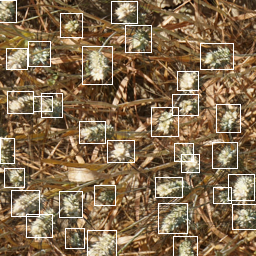

In [44]:
from PIL import ImageDraw 
drw = ImageDraw.Draw(IMG)

for (x,y,w,h) in valid_filtered_bboxes[img]:
    drw.rectangle([x, y, w, h])

IMG

In [39]:
def pil_fromarray(arr):
    img = Image.fromarray(np.array(arr, "uint8"), "RGB")
    drw = ImageDraw.Draw(img)
    return img, drw

def draw_bboxes(drw, bboxes, truth):
    for bbox in bboxes:
        x, y, x2, y2 = bbox 
        if truth:
            x2 += x 
            y2 += y
        drw.rectangle([x, y, x2, y2], width=2, outline="red")
    return drw  

def getPlotImage(arr, bboxes, truth = False):
    img, drw = pil_fromarray(arr)
    draw_bboxes(drw, bboxes, truth)
    return img

def show_images(image_list, image_pixels, y_pred, y_true):
    images = random.sample([i for i in image_list], 5)

    fig, ax = plt.subplots(5, 2, figsize = (9, 25))
    predicted_text = f"\33[38;2;255;;100mPredicted\33[m"
    actual_text = f"\33[38;2;255;;100mActual\33[m"
    for i in range(5):
        name = images[i]
        actual = np.array(getPlotImage(image_pixels[name], y_true[name], True).convert("RGB"))
        ax[i, 0].imshow(actual)
        ax[i, 0].axis("off")
        ax[i, 0].set_title("Actual")
        predicted = np.array(getPlotImage(image_pixels[name], y_pred[name]).convert("RGB"))
        ax[i, 1].imshow(predicted)
        ax[i, 1].axis("off")
        ax[i, 1].set_title("Predicted")
    plt.show()

/tmp/ipykernel_58/3419819472.py:2: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np.array(arr, "uint8"), "RGB")


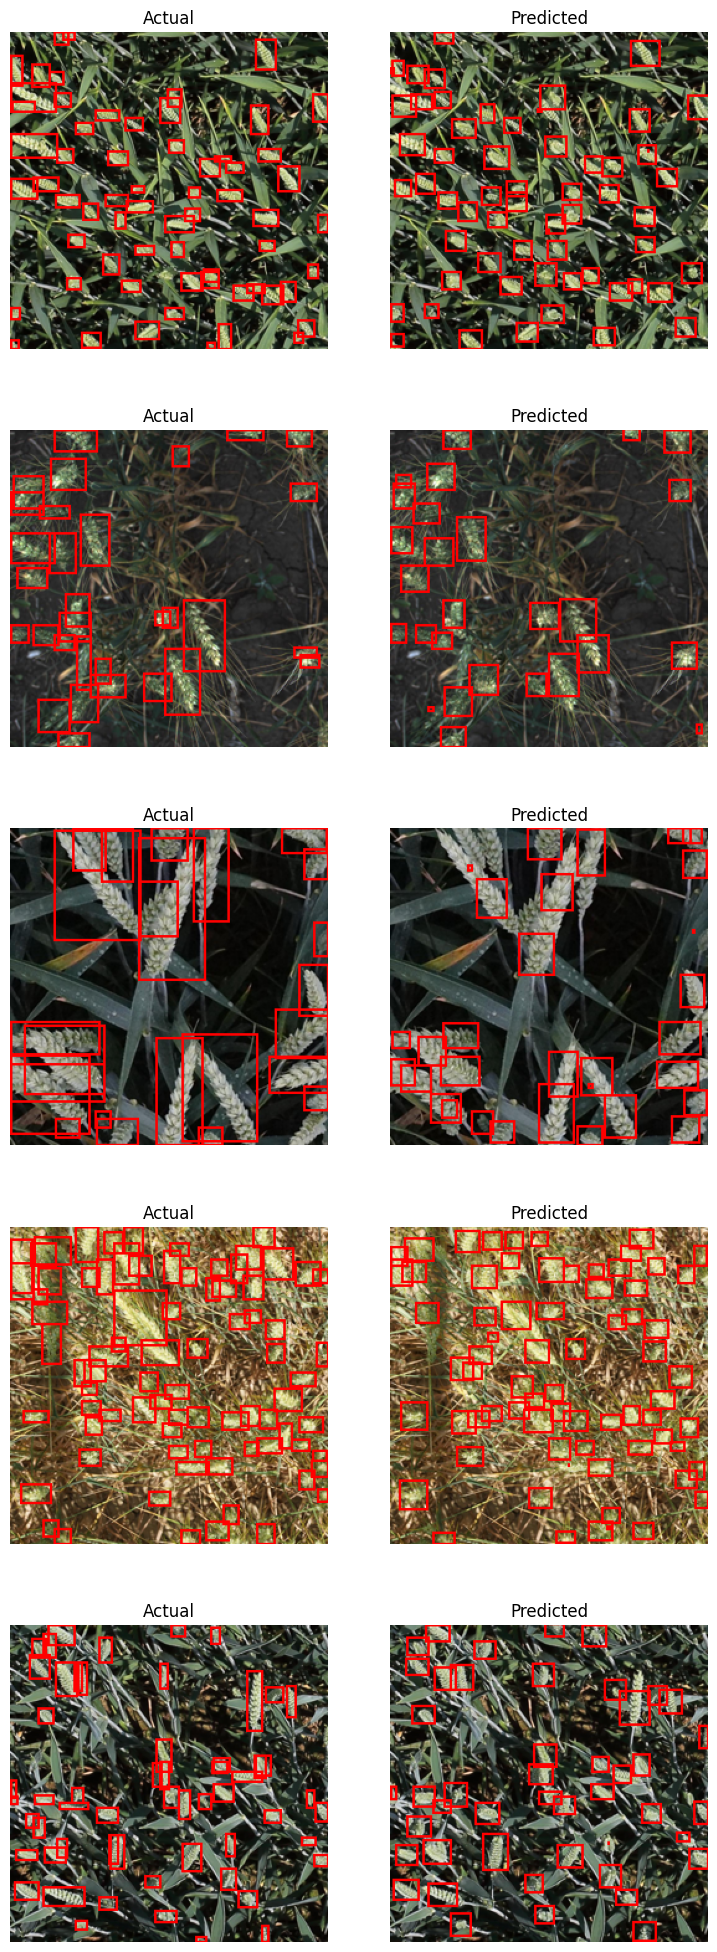

In [45]:
show_images(valid_images, valid_pixels, valid_filtered_bboxes, valid_bboxes)

As we can see our custom model is capable of producing highly accurate predictions even when its only trained on 3K images which have 6-7 different sources.

#### To Improve Quality and detection accuracy of our model even further we can perform following techniques:
1. Augment images with Albumentations, OpenCV etc. as Augmenting images for training helps in better generalization of models.
2. Our model is performing 1 bounding box prediction on each cell grid which can be increased on whatever amount we like, but it will also going to increase training cost and time.
3. For this specific problem 2 bounding box prediction for each cell grid would be optimal.
4. We can also increase cell grid size from 16x16 to 32x32 or even more. But it also increases training cost and time.